In [1]:
import pandas as pd
from sqlalchemy import create_engine

In [ ]:
df=pd.read_csv('data/superstore.csv',encoding='latin1')
df.columns=df.columns.str.lower().str.replace(' ','_')
df['order_date']=pd.to_datetime(df['order_date'])
df['ship_date']=pd.to_datetime(df['ship_date'])

In [7]:
df['profit_margin']=df['profit']/df['sales']
df['ship_lag_days']   = (df['ship_date'] - df['order_date']).dt.days
df['order_year']      = df['order_date'].dt.year
df['order_month']     = df['order_date'].dt.month
df['order_quarter']   = df['order_date'].dt.quarter

In [9]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df[['sales','profit','discount']].describe())
print(f'Negative profit rows: {(df["profit"] < 0).sum()}')

(9994, 26)
row_id                    int64
order_id                    str
order_date       datetime64[us]
ship_date        datetime64[us]
ship_mode                   str
customer_id                 str
customer_name               str
segment                     str
country                     str
city                        str
state                       str
postal_code               int64
region                      str
product_id                  str
category                    str
sub-category                str
product_name                str
sales                   float64
quantity                  int64
discount                float64
profit                  float64
profit_margin           float64
ship_lag_days             int64
order_year                int32
order_month               int32
order_quarter             int32
dtype: object
row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment   

In [11]:
engine=create_engine('sqlite:///superstore.db')
df.to_sql('orders', engine, if_exists='replace', index=False)
print('Database created: superstore.db')


Database created: superstore.db


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


# ---CHART 1: Monthly revenue time-series---

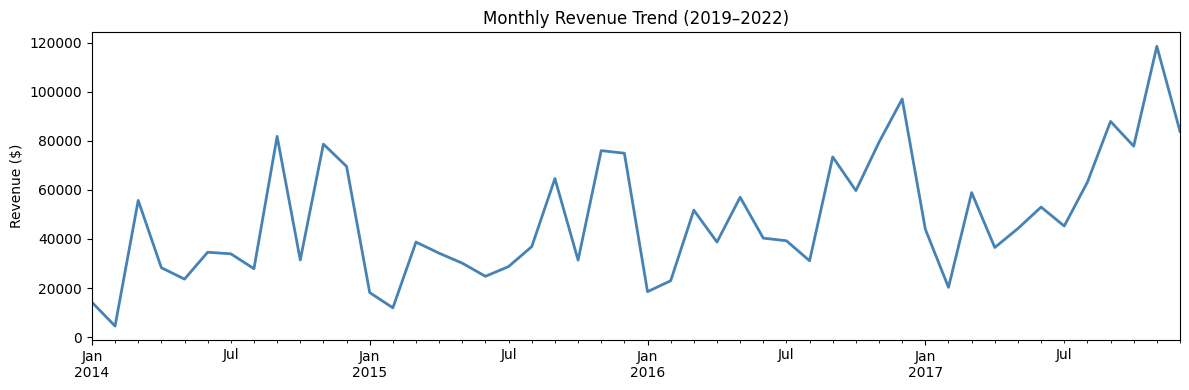

Best month:  2017-11  $118,448
Worst month: 2014-02  $4,520


In [ ]:
monthly = df.groupby(df['order_date'].dt.to_period('M'))['sales'].sum()

plt.figure(figsize=(12, 4))
monthly.plot(color='steelblue', linewidth=2)
plt.ylabel('Revenue ($)')
plt.xlabel('')
plt.title('Monthly Revenue Trend (2019–2022)')
plt.tight_layout()
plt.savefig('dashboard/screenshots/chart1_monthly_revenue.png', dpi=150)
plt.show()

print(f"Best month:  {monthly.idxmax()}  ${monthly.max():,.0f}")
print(f"Worst month: {monthly.idxmin()}  ${monthly.min():,.0f}")

# ---Chart 2: Profit margin by sub-category (sorted)---

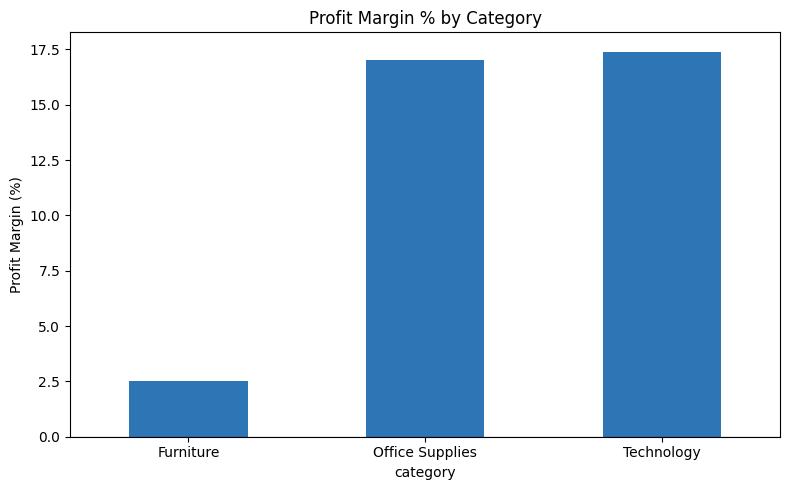

                     revenue       profit  margin
category                                         
Furniture        741999.7953   18451.2728     2.5
Office Supplies  719047.0320  122490.8008    17.0
Technology       836154.0330  145454.9481    17.4


In [ ]:
cat = df.groupby('category').agg(
    revenue=('sales', 'sum'),
    profit=('profit', 'sum')
).assign(margin=lambda x: (x['profit'] / x['revenue'] * 100).round(1))

colors = ['#E24B4A' if m < 0 else '#2E75B6' for m in cat['margin']]
cat['margin'].plot(kind='bar', figsize=(8, 5), color=colors, width=0.5)
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=0)
plt.ylabel('Profit Margin (%)')
plt.title('Profit Margin % by Category')
plt.tight_layout()
plt.savefig('dashboard/screenshots/chart2_category_margin.png', dpi=150)
plt.show()

print(cat[['revenue', 'profit', 'margin']])

# ---Chart 3: Regional Performance---

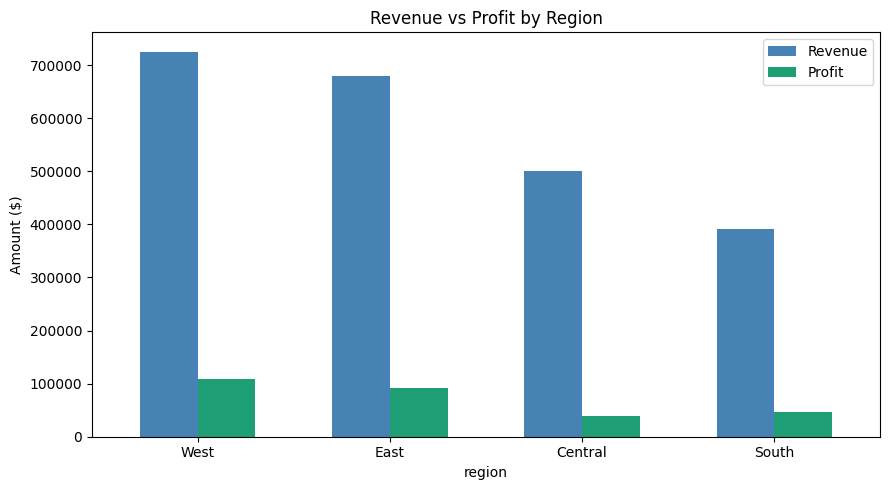

             revenue       profit  margin
region                                   
West     725457.8245  108418.4489    14.9
East     678781.2400   91522.7800    13.5
Central  501239.8908   39706.3625     7.9
South    391721.9050   46749.4303    11.9


In [ ]:
region = df.groupby('region').agg(
    revenue=('sales', 'sum'),
    profit=('profit', 'sum')
).assign(margin=lambda x: (x['profit'] / x['revenue'] * 100).round(1)) \
 .sort_values('revenue', ascending=False)

region[['revenue', 'profit']].plot(kind='bar', figsize=(9, 5),
                                    color=['steelblue', '#1D9E75'],
                                    width=0.6)
plt.xticks(rotation=0)
plt.ylabel('Amount ($)')
plt.title('Revenue vs Profit by Region')
plt.legend(['Revenue', 'Profit'])
plt.tight_layout()
plt.savefig('dashboard/screenshots/chart3_regional_performance.png', dpi=150)
plt.show()

print(region)

# ---Chart 4: Discount Analysis---

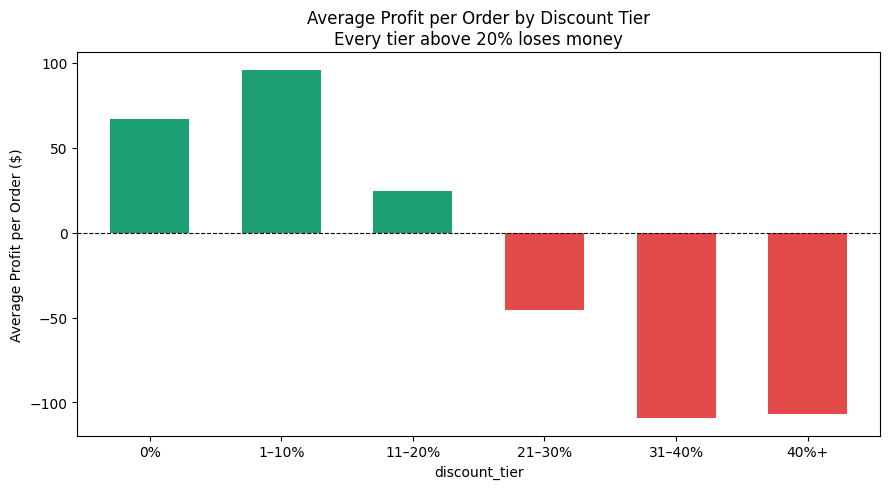

               orders  avg_profit  total_profit
discount_tier                                  
0%               4798       66.90     320987.60
1–10%              94       96.06       9029.18
11–20%           3709       24.74      91756.30
21–30%            227      -45.68     -10369.28
31–40%            233     -109.22     -25448.19
40%+              933     -106.71     -99558.59


In [ ]:
df['discount_tier'] = pd.cut(
    df['discount'],
    bins=[-0.01, 0, 0.10, 0.20, 0.30, 0.40, 1.0],
    labels=['0%', '1–10%', '11–20%', '21–30%', '31–40%', '40%+']
)

discount = df.groupby('discount_tier', observed=True)['profit'].mean()

colors = ['#1D9E75' if v > 0 else '#E24B4A' for v in discount]
discount.plot(kind='bar', figsize=(9, 5), color=colors, width=0.6)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xticks(rotation=0)
plt.ylabel('Average Profit per Order ($)')
plt.title('Average Profit per Order by Discount Tier\nEvery tier above 20% loses money')
plt.tight_layout()
plt.savefig('dashboard/screenshots/chart4_discount_analysis.png', dpi=150)
plt.show()

print(df.groupby('discount_tier', observed=True).agg(
    orders=('profit', 'count'),
    avg_profit=('profit', 'mean'),
    total_profit=('profit', 'sum')
).round(2))

# ---Chart 5: Top customers by revenue---

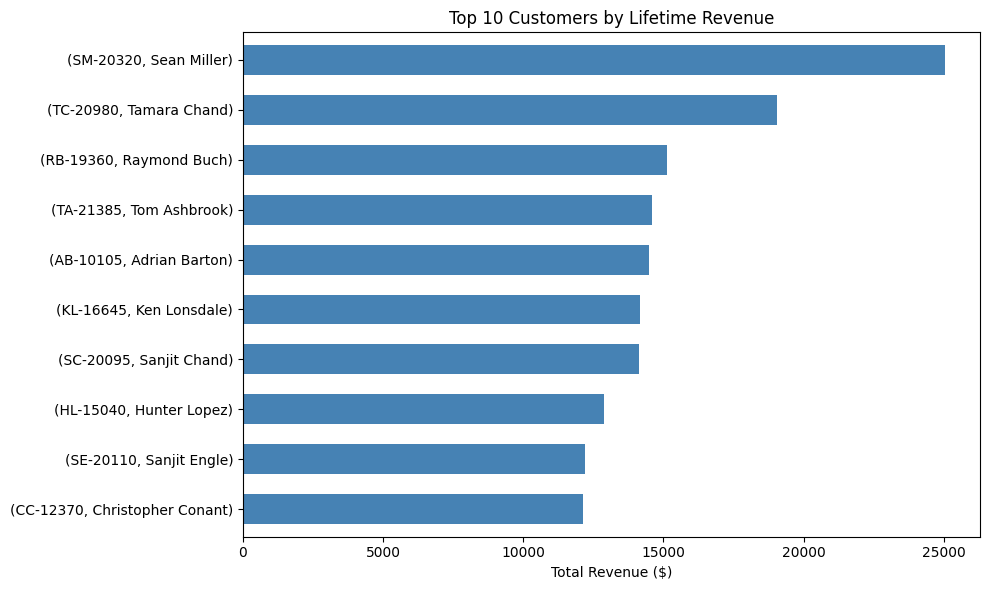

                                 revenue   profit  orders
customer_id customer_name                                
SM-20320    Sean Miller         25043.05 -1980.74       5
TC-20980    Tamara Chand        19052.22  8981.32       5
RB-19360    Raymond Buch        15117.34  6976.10       6
TA-21385    Tom Ashbrook        14595.62  4703.79       4
AB-10105    Adrian Barton       14473.57  5444.81      10
KL-16645    Ken Lonsdale        14175.23   806.86      12
SC-20095    Sanjit Chand        14142.33  5757.41       9
HL-15040    Hunter Lopez        12873.30  5622.43       6
SE-20110    Sanjit Engle        12209.44  2650.68      11
CC-12370    Christopher Conant  12129.07  2177.05       5


In [ ]:
customers = df.groupby(['customer_id', 'customer_name']).agg(
    revenue=('sales', 'sum'),
    profit=('profit', 'sum'),
    orders=('order_id', 'nunique')
).sort_values('revenue', ascending=False).head(10)

colors = ['#1D9E75' if p > 0 else '#E24B4A' for p in customers['profit']]
customers['revenue'].plot(kind='barh', figsize=(10, 6),
                           color='steelblue', width=0.6)
plt.xlabel('Total Revenue ($)')
plt.ylabel('')
plt.title('Top 10 Customers by Lifetime Revenue')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('dashboard/screenshots/chart5_top_customers.png', dpi=150)
plt.show()

print(customers[['revenue', 'profit', 'orders']].round(2))